# VI. Prediction and Model Evaluation

- Fit at least one predictive model (e.g., logistic regression)
- Use train/test split or cross-validation
- Evaluate performance:
  - AUC / ROC (classification)
  - MSE (regression)
- Explain results in plain language

**Prediction Question:** Is it possible to predict GPA for a new student?

In [138]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [139]:
# Load Data

data = pd.read_csv("../data/prepared_student_data.csv")

In [140]:
data.head()

,age,study_hours,study_seatings,social_media_hours,attendance,skill_hours,semester_gpa,cumulative_gpa,credits,family_income,...,skills_programming,skills_software_development,skills_web_development,interest_area_data_science,interest_area_hardware,interest_area_machine_learning,interest_area_networking,interest_area_other,interest_area_software,interest_area_ui/ux
0,24,3,2,5,90.0,2,2.68,3.15,75,25000,...,0,1,0,0,0,0,0,1,0,0
1,22,3,2,3,96.0,2,2.68,3.15,36,100000,...,0,0,1,0,0,0,0,1,0,0
2,21,3,3,3,80.0,1,2.68,3.15,50,50000,...,1,0,0,0,0,0,0,0,1,0
3,20,1,3,2,88.0,1,2.68,3.15,36,62488,...,1,0,0,0,0,0,0,0,0,0
4,22,3,1,2,80.0,1,2.68,3.15,36,50000,...,1,0,0,0,0,0,0,0,1,0


In [141]:
# Separate features and target

X = data.drop(columns=['semester_gpa', 'cumulative_gpa'])
y = data[['cumulative_gpa']]

In [142]:
# Perform train/test split

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=3026)

### Linear Regression

In [143]:
# Standardize features

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [144]:
# Perform linear regression

lr_model = LinearRegression()

lr_model.fit(X_train_scaled, y_train)


LinearRegression()

In [145]:
# Evaluate model performance on test set

y_pred = lr_model.predict(X_test_scaled)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5

print(f"R2 Score: {round(r2, 4)}")
print(f"MAE: {round(mae, 4)}")
print(f"MSE: {round(mse, 4)}")
print(f"RMSE: {round(rmse, 4)}")

R2 Score: 0.0711
MAE: 0.5115
MSE: 0.5726
RMSE: 0.7567


In [146]:
# Evaluate feature importance

feature_importance = pd.DataFrame({
    "feature": X.columns,
    "coefficient": abs(lr_model.coef_.ravel())
})

feature_importance = feature_importance.sort_values(by='coefficient', ascending=False)

print(feature_importance)

                             feature  coefficient
6                            credits     0.246186
10                  health_issues_no     0.171776
20                      skills_other     0.163416
13                   scholarship_yes     0.137054
11                 health_issues_yes     0.132205
29            interest_area_software     0.094564
4                         attendance     0.072522
0                                age     0.057930
19                 skills_networking     0.050325
3                 social_media_hours     0.041514
16                  disabilities_yes     0.041110
24        interest_area_data_science     0.037951
21                skills_programming     0.033866
30               interest_area_ui/ux     0.033613
17             skills_cyber_security     0.032259
14                       gender_male     0.030310
5                        skill_hours     0.028531
27          interest_area_networking     0.026000
22       skills_software_development     0.023840


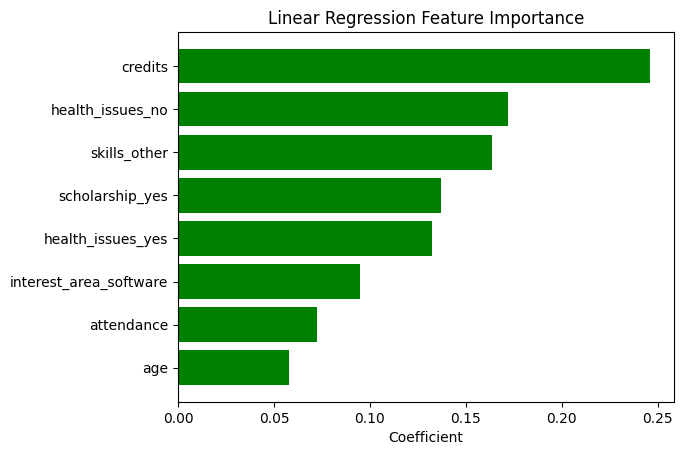

In [147]:
# Visualize feature importance 

top_features = feature_importance.head(8)

plt.figure()
plt.barh(top_features['feature'], top_features['coefficient'], color="green")
plt.title("Linear Regression Feature Importance")
plt.xlabel("Coefficient")
plt.gca().invert_yaxis()
plt.show()

#### Interpretation

The Linear Regression model performs poorly at predicting the GPA of unseen students. The model achieves a low R2 score of 0.07, meaning only 7% of the variance in GPA can be explained by features included in the model. This indicates that the model is not effective at predicting GPA reliably. The model scored an RMSE of 0.76, meaning that typical prediction had an error of 0.76 points. This is high considering GPA runs on a scale of 0 - 4.0.

The most influential features in the linear regression model are:
1) number of credits taken
2) presence of health issues
3) student is pursuing skills in the "other" category
4) scholarship status of student
This ties into our inferential question, where it is statistically significant that a student's scholarship status is associated with their GPA.